
**Language Model**: `Qwen/Qwen3-8B`  
**Embedding Model**: `Qwen/Qwen3-Embedding-8B`  

---


#**TAHAP 1 (PRA-PEMROSESAN DATA)**

#install library

In [ ]:
%pip -q uninstall -y transformers
%pip -q install --no-cache-dir "transformers>=4.51.0" "sentence-transformers>=2.7.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 160.6 MB/s eta 0:00:00


In [ ]:
%pip -q install -U "transformers>=4.51.0" accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00


restart yaa

In [ ]:
#cek versi transformers
import transformers
print("transformers:", transformers.__version__)

transformers: 5.9.0


In [ ]:
#install faiss
%pip -q uninstall -y faiss faiss-cpu
%pip -q install --no-cache-dir "numpy<2" "faiss-cpu"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 207.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 179.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.


restart lagi yaa

In [ ]:
import sys, platform, numpy as np, pandas as pd

print("python:", sys.version.split()[0], "| platform:", platform.platform())
print("numpy:", np.__version__, "| pandas:", pd.__version__)

import faiss
print("faiss:", faiss.__version__)

python: 3.12.13 | platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy: 1.26.4 | pandas: 2.2.2
faiss: 1.14.2


#Login HuggingFace (untuk model publik: Qwen3-8B)

In [ ]:
# Qwen3-8B adalah model publik (Apache 2.0) — TIDAK perlu HF token
# Variable HF_TOKEN_LM tetap didefinisikan = None untuk kompatibilitas dengan cell-cell berikutnya
# yang masih melewatkan parameter `token=HF_TOKEN_LM` ke from_pretrained()

HF_TOKEN_LM = None
print('Qwen3-8B publik — tidak perlu HF token')


Qwen3-8B publik — tidak perlu HF token


#Load dataset

In [ ]:
# === Dataset ===
DATASET_NAME = "rajpurkar/squad_v2"
SPLIT = "validation"

# === Retriever embedding model
RETRIEVERS = {
    "e5": "Qwen/Qwen3-Embedding-8B",
}

RETRIEVER_KEY = "e5"
EMBED_MODEL_NAME = RETRIEVERS[RETRIEVER_KEY]

print("Embedding model:", EMBED_MODEL_NAME)


Embedding model: Qwen/Qwen3-Embedding-8B


In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("rajpurkar/squad_v2", split="validation")

df6 = pd.DataFrame(ds.select(range(6)))
df6

README.md:   0%|          | 0.00/8.92k [00:00<?, ?B/s]

squad_v2/train-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

squad_v2/validation-00000-of-00001.parqu(…):   0%|          | 0.00/1.35M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

,id,title,context,question,answers
0,56ddde6b9a695914005b9628,Normans,The Normans (Norman: Nourmands; French: Norman...,In what country is Normandy located?,"{'text': ['France', 'France', 'France', 'Franc..."
1,56ddde6b9a695914005b9629,Normans,The Normans (Norman: Nourmands; French: Norman...,When were the Normans in Normandy?,"{'text': ['10th and 11th centuries', 'in the 1..."
2,56ddde6b9a695914005b962a,Normans,The Normans (Norman: Nourmands; French: Norman...,From which countries did the Norse originate?,"{'text': ['Denmark, Iceland and Norway', 'Denm..."
3,56ddde6b9a695914005b962b,Normans,The Normans (Norman: Nourmands; French: Norman...,Who was the Norse leader?,"{'text': ['Rollo', 'Rollo', 'Rollo', 'Rollo'],..."
4,56ddde6b9a695914005b962c,Normans,The Normans (Norman: Nourmands; French: Norman...,What century did the Normans first gain their ...,"{'text': ['10th century', 'the first half of t..."
5,5ad39d53604f3c001a3fe8d1,Normans,The Normans (Norman: Nourmands; French: Norman...,Who gave their name to Normandy in the 1000's ...,"{'text': [], 'answer_start': []}"


In [ ]:
# variabel yang akan digunakan
ds_no_title = ds.remove_columns(["title"])

df6_no_title = pd.DataFrame(ds_no_title.select(range(6)))
df6_no_title


,id,context,question,answers
0,56ddde6b9a695914005b9628,The Normans (Norman: Nourmands; French: Norman...,In what country is Normandy located?,"{'text': ['France', 'France', 'France', 'Franc..."
1,56ddde6b9a695914005b9629,The Normans (Norman: Nourmands; French: Norman...,When were the Normans in Normandy?,"{'text': ['10th and 11th centuries', 'in the 1..."
2,56ddde6b9a695914005b962a,The Normans (Norman: Nourmands; French: Norman...,From which countries did the Norse originate?,"{'text': ['Denmark, Iceland and Norway', 'Denm..."
3,56ddde6b9a695914005b962b,The Normans (Norman: Nourmands; French: Norman...,Who was the Norse leader?,"{'text': ['Rollo', 'Rollo', 'Rollo', 'Rollo'],..."
4,56ddde6b9a695914005b962c,The Normans (Norman: Nourmands; French: Norman...,What century did the Normans first gain their ...,"{'text': ['10th century', 'the first half of t..."
5,5ad39d53604f3c001a3fe8d1,The Normans (Norman: Nourmands; French: Norman...,Who gave their name to Normandy in the 1000's ...,"{'text': [], 'answer_start': []}"


#EDA

In [ ]:
ds = ds.remove_columns(["title"])
df_eda = ds.to_pandas()

Rows: 11873
Columns: ['id', 'context', 'question', 'answers']

Missing values (key columns):
No missing values in key columns.

Duplicate rows (based on id/context/question): 0

Label distribution:
                      count    pct
is_unanswerable                   
Unanswerable (NoAns)   5945  50.07
Answerable (HasAns)    5928  49.93


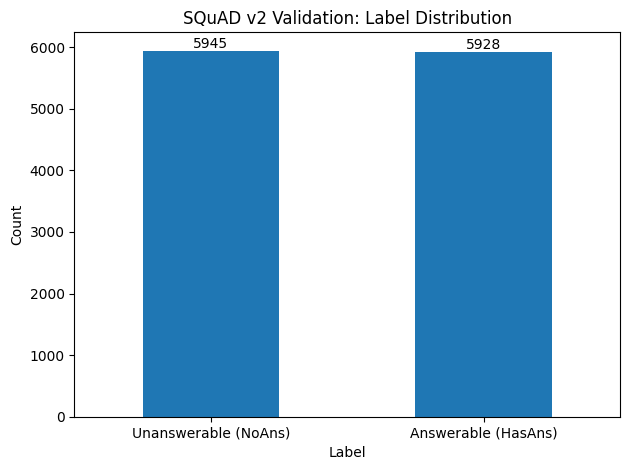

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Rows:", len(df_eda))
print("Columns:", df_eda.columns.tolist())

# --- Missing values
cols_key = ["id", "context", "question", "answers"]
missing = df_eda[cols_key].isna().sum()
print("\nMissing values (key columns):")
print(missing[missing > 0] if (missing > 0).any() else "No missing values in key columns.")

# --- FIX 1: Duplicate rows
dup_rows = df_eda.duplicated(subset=["id", "context", "question"]).sum()
print("\nDuplicate rows (based on id/context/question):", dup_rows)

# --- FIX 2: Label distribution
def is_unanswerable(a):
    try:
        return len(a.get("text", [])) == 0
    except:
        return True

df_eda["is_unanswerable"] = df_eda["answers"].apply(is_unanswerable)

label_counts = df_eda["is_unanswerable"].value_counts()
label_pct = (label_counts / len(df_eda) * 100).round(2)
out = pd.DataFrame({"count": label_counts, "pct": label_pct})
out.index = out.index.map({False: "Answerable (HasAns)", True: "Unanswerable (NoAns)"})
print("\nLabel distribution:")
print(out)

# --- Grafik bar label distribution ---
fig, ax = plt.subplots()

ax = out["count"].plot(kind="bar", color="#1f77b4", ax=ax)

ax.set_title("SQuAD v2 Validation: Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# kasih angka di atas bar
for i, p in enumerate(ax.patches):
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h,
        f"{int(h)}",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()


#cleaning

In [ ]:
# 3) CLEANING RINGAN
import re

def clean_minimal(text: str) -> str:
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Cleaning seluruh context
contexts_all_raw = ds["context"]
contexts_all_clean = [clean_minimal(t) for t in contexts_all_raw]

print("RAW  :", contexts_all_raw[0][:160])
print("CLEAN:", contexts_all_clean[0][:160])


RAW  : The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in F
CLEAN: The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in F


In [ ]:
# 2) PASSAGE CONSTRUCTION
# - corpus untuk retrieval = kumpulan context unik
from collections import Counter

# Hitung berapa pertanyaan per context
ctx_count = Counter(contexts_all_clean)

# Dedup stable
unique_contexts = list(dict.fromkeys(contexts_all_clean))

rep_raw = {}
for raw, clean in zip(contexts_all_raw, contexts_all_clean):
    if clean not in rep_raw:
        rep_raw[clean] = raw
unique_contexts_raw = [rep_raw[c] for c in unique_contexts]

print("Total QA pairs:", len(ds))
print("Unique contexts (after cleaning):", len(unique_contexts))
print("Rata-rata pertanyaan per context:", round(len(ds) / len(unique_contexts), 2))

# komposisi HasAns / NoAns (berdasarkan answers)
has_ans = [len(a["text"]) > 0 for a in ds["answers"]]
print("HasAns:", int(np.sum(has_ans)), "| NoAns:", int(len(has_ans) - np.sum(has_ans)))


Total QA pairs: 11873
Unique contexts (after cleaning): 1204
Rata-rata pertanyaan per context: 9.86
HasAns: 5928 | NoAns: 5945


rata-rata tiap context digunakan oleh 9.86 pertanyaan. Ini menunjukkan satu paragraf dipakai berulang, sehingga corpus untuk retrieval dibentuk dari context unik agar index tidak berisi duplikasi.

In [ ]:
raw = "Kalimat 1.\n\nKalimat 2.\tAda TAB.\n   Banyak     spasi."
print("RAW  :", repr(raw))
print("CLEAN:", repr(clean_minimal(raw)))


RAW  : 'Kalimat 1.\n\nKalimat 2.\tAda TAB.\n   Banyak     spasi.'
CLEAN: 'Kalimat 1. Kalimat 2. Ada TAB. Banyak spasi.'


#bukti empiris tidak ada chunking

In [ ]:
# 4) "BUKTI EMPIRIS" kenapa tidak perlu chunking eksplisit:
# hitung distribusi panjang token context.

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(
    EMBED_MODEL_NAME,
    use_fast=False,  # aman untuk beberapa tokenizer
)

def token_lengths(texts, batch_size=32):
    lens = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, add_special_tokens=False, truncation=False)
        lens.extend([len(ids) for ids in enc["input_ids"]])
    return np.array(lens, dtype=np.int32)

lengths = token_lengths(unique_contexts, batch_size=32)

stats = {
    "n_unique_contexts": int(len(lengths)),
    "min": int(lengths.min()),
    "median(p50)": int(np.percentile(lengths, 50)),
    "p90": int(np.percentile(lengths, 90)),
    "p95": int(np.percentile(lengths, 95)),
    "max": int(lengths.max()),
    "%<=512": float((lengths <= 512).mean()),
    "%<=1024": float((lengths <= 1024).mean()),
}

pd.DataFrame([stats])


config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.26k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

,n_unique_contexts,min,median(p50),p90,p95,max,%<=512,%<=1024
0,1204,30,153,261,305,788,0.993355,1.0


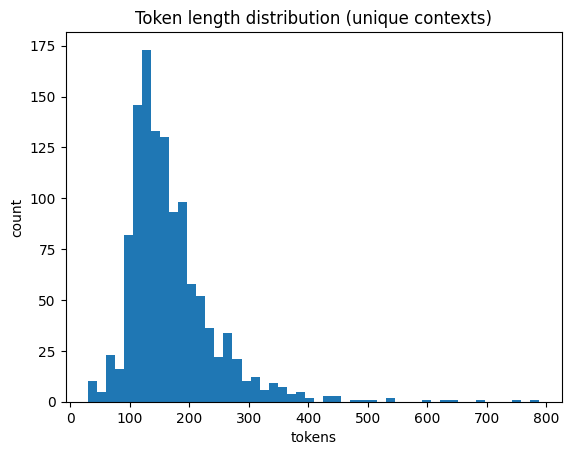

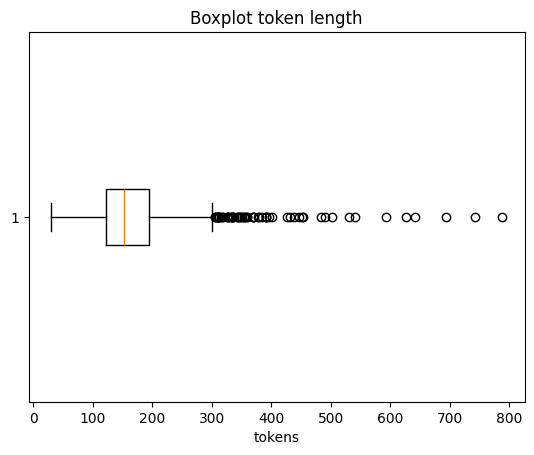

In [ ]:
# Visualisasi
import matplotlib.pyplot as plt

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Token length distribution (unique contexts)")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()

plt.figure()
plt.boxplot(lengths, vert=False)
plt.title("Boxplot token length")
plt.xlabel("tokens")
plt.show()


In [ ]:
# Lihat beberapa context terpanjang (opsional)
top_idx = np.argsort(-lengths)[:3]
for rank, idx in enumerate(top_idx, 1):
    ctx_clean = unique_contexts[idx]
    occ = ctx_count[ctx_clean]
    print(f"\n=== TOP {rank} | tokens={int(lengths[idx])} | occurrences={occ} ===")
    # tampilkan versi clean + (opsional) raw representatif untuk referensi
    print(ctx_clean[:600])



=== TOP 1 | tokens=788 | occurrences=9 ===
The "freedom to provide services" under TFEU article 56 applies to people who give services "for remuneration", especially commercial or professional activity. For example, in Van Binsbergen v Bestuur van de Bedrijfvereniging voor de Metaalnijverheid a Dutch lawyer moved to Belgium while advising a client in a social security case, and was told he could not continue because Dutch law said only people established in the Netherlands could give legal advice. The Court of Justice held that the freedom to provide services applied, it was directly effective, and the rule was probably unjustified: ha

=== TOP 2 | tokens=743 | occurrences=14 ===
Both X.25 and Frame Relay provide connection-oriented operations. But X.25 does it at the network layer of the OSI Model. Frame Relay does it at level two, the data link layer. Another major difference between X.25 and Frame Relay is that X.25 requires a handshake between the communicating parties before any 

#embedding

In [ ]:
import torch
from transformers import BitsAndBytesConfig
from sentence_transformers import SentenceTransformer

FAST_N = None
passages = unique_contexts if FAST_N is None else unique_contexts[:FAST_N]

def format_passage(text: str):
    return text

def format_query(text: str):
    return text

EMBED_MODEL_NAME = "Qwen/Qwen3-Embedding-8B"

st_model = SentenceTransformer(
    EMBED_MODEL_NAME,
    device="cuda",
    model_kwargs={
        "quantization_config": BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
        ),
    },  # 4-bit quantization untuk Qwen3-Embedding-8B agar muat T4 (15GB)
)
st_model.max_seq_length = 1024

# encode passages
p_emb = st_model.encode(
    [format_passage(t) for t in passages],
    batch_size=1,  # 8B model
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype(np.float32)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Batches:   0%|          | 0/1204 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

n_rows = 3          # mau tampil p0, p1, p2
dim_last = p_emb.shape[1]   # 896
dims_head = [1, 2]  # mau tampil Dimensi 1 & 2 (bisa tambah)

# ambil baris
X = p_emb[:n_rows, :]

# bikin tabel
df = pd.DataFrame({
    "Nomor": list(range(n_rows)),
    "Passage id": [f"p{i}" for i in range(n_rows)],
})

# kolom dimensi awal
for d in dims_head:
    df[f"Dimensi {d}"] = X[:, d-1]

# kolom titik-titik
df["....."] = "..."

# kolom dimensi terakhir
df[f"Dimensi {dim_last}"] = X[:, dim_last-1]

df

,Nomor,Passage id,Dimensi 1,Dimensi 2,.....,Dimensi 4096
0,0,p0,-0.009216,0.026367,...,0.011108
1,1,p1,-0.022827,0.029297,...,0.013550
2,2,p2,0.015747,0.000633,...,0.006989


#indexing

In [ ]:
# --- Build index: FAISS kalau ada, fallback ke sklearn kalau tidak ---
try:
    import faiss
    dim = p_emb.shape[1]
    index = faiss.IndexFlatIP(dim)  # cosine ~ inner product karena normalize
    index.add(p_emb)
    INDEX_BACKEND = "faiss"
except Exception as e:
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=10, metric="cosine")
    nn.fit(p_emb)
    index = nn
    INDEX_BACKEND = "sklearn"
    print("FAISS tidak tersedia, pakai sklearn. Error:", repr(e))

print("Index backend:", INDEX_BACKEND, "| passages indexed:", len(passages), "| dim:", p_emb.shape[1])

Index backend: faiss | passages indexed: 1204 | dim: 4096


In [ ]:
import pandas as pd
import numpy as np

query_id = np.random.randint(0, len(ds))
query = ds["question"][query_id]

# bikin mapping: tiap passage (context) -> 1 contoh question dari dataset
rep_question = {}
for q, ctx in zip(ds["question"], contexts_all_clean):
    if ctx not in rep_question:
        rep_question[ctx] = q

q_emb = st_model.encode([format_query(query)], normalize_embeddings=True)

D, I = index.search(q_emb, k=3)

rows = []
for rank, (score, idx) in enumerate(zip(D[0], I[0]), start=1):
    passage = passages[int(idx)]
    rows.append([
        rank,
        float(score),
        passage[:120] + "...",
        rep_question.get(passage, "")
    ])

df_top = pd.DataFrame(
    rows,
    columns=["Peringkat", "Skor Kemiripan", "Potongan Teks", "Question"]
)

df_top

,Peringkat,Skor Kemiripan,Potongan Teks,Question
0,1,0.620136,The immune system protects organisms from infe...,What type of immune systems are found in all p...
1,2,0.606218,"Pathogens can rapidly evolve and adapt, and th...",The immune systems of bacteria have enzymes th...
2,3,0.601304,Microorganisms or toxins that successfully ent...,What part of the innate immune system identifi...


#save gdrive

save ke gdrive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


save artifacts (passages, p_emb, faiss index, meta)

In [ ]:
import os, json, numpy as np, faiss

SAVE_DIR = "/content/drive/MyDrive/strategiB-LLM-qwen3-8b"  # boleh ganti nama folder
os.makedirs(SAVE_DIR, exist_ok=True)

with open(os.path.join(SAVE_DIR, "passages.json"), "w", encoding="utf-8") as f:
    json.dump(passages, f, ensure_ascii=False)

np.save(os.path.join(SAVE_DIR, "p_emb.npy"), p_emb)

faiss.write_index(index, os.path.join(SAVE_DIR, "faiss.index"))

meta = {
    "embed_model": EMBED_MODEL_NAME,
    "p_emb_shape": list(p_emb.shape),
    "p_emb_dtype": str(p_emb.dtype),
    "faiss_index_type": type(index).__name__,
}
with open(os.path.join(SAVE_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved to:", SAVE_DIR)
print("Files:", os.listdir(SAVE_DIR))

Saved to: /content/drive/MyDrive/strategiB-LLM-qwen3-8b
Files: ['passages.json', 'p_emb.npy', 'faiss.index', 'meta.json']


RESTART

abis restart, load lagi yg uda di sv

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===== OUTPUT SETTINGS (SATU TEMPAT UNTUK SEMUA OUTPUT) =====
import os

# Semua output (config 1-4) akan masuk ke folder ini:
OUT_DIR = "/content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print("OUT_DIR:", OUT_DIR)

OUT_DIR: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs


load artifacts untuk tahap selanjutnya

In [ ]:
import os, json, numpy as np, faiss

SAVE_DIR = "/content/drive/MyDrive/strategiB-LLM-qwen3-8b"

passages = json.load(open(os.path.join(SAVE_DIR, "passages.json"), "r", encoding="utf-8"))
p_emb = np.load(os.path.join(SAVE_DIR, "p_emb.npy"))
index = faiss.read_index(os.path.join(SAVE_DIR, "faiss.index"))

print("Loaded:", len(passages), p_emb.shape, "| index ntotal:", index.ntotal)

Loaded: 1204 (1204, 4096) | index ntotal: 1204


In [ ]:
#cek ram
!nvidia-smi

Wed Jun  3 01:10:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#**TAHAP 2 (USER)**

#embed query

In [ ]:
#re-embed
import torch
from transformers import BitsAndBytesConfig
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "Qwen/Qwen3-Embedding-8B"

device = "cuda" if torch.cuda.is_available() else "cpu"

st_model = SentenceTransformer(
    EMBED_MODEL_NAME,
    device=device,
    model_kwargs={
        "quantization_config": BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
        ),
    } if device == "cuda" else {}  # 4-bit quantization untuk muat T4
)

st_model.max_seq_length = 1024

# Task description spesifik untuk QA SQuAD (sebelumnya: "web search query")
TASK_DESC = "Given a question, retrieve relevant passages that answer the question"

def format_query(text: str) -> str:
    return f"Instruct: {TASK_DESC}\nQuery: {text}"

def format_passage(text: str) -> str:
    return text

print("st_model ready on:", device)
print("EMBED_MODEL_NAME:", EMBED_MODEL_NAME)
print("max_seq_length:", st_model.max_seq_length)
print("TASK_DESC:", TASK_DESC)
print("Query format example:")
print(format_query("In what country is Normandy located?"))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

st_model ready on: cuda
EMBED_MODEL_NAME: Qwen/Qwen3-Embedding-8B
max_seq_length: 1024
TASK_DESC: Given a question, retrieve relevant passages that answer the question
Query format example:
Instruct: Given a question, retrieve relevant passages that answer the question
Query: In what country is Normandy located?


embed queryyy

In [ ]:
import numpy as np
from datasets import load_dataset

# 1) Load dataset
ds = load_dataset("rajpurkar/squad_v2", split="validation").remove_columns(["title"])

# 2) Ambil 100 pertanyaan
N_QUERIES = 100
queries = ds["question"][:N_QUERIES]

# 3) Embed queries — prefix sudah di format_query, JANGAN pakai prompt_name lagi
q_emb = st_model.encode(
    [format_query(q) for q in queries],
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
    batch_size=1,  # konservatif untuk Qwen3-Embedding-8B
).astype(np.float32)

print("queries:", len(queries))
print("q_emb shape:", q_emb.shape, "| dtype:", q_emb.dtype)
print("dim match p_emb:", (q_emb.shape[1] == p_emb.shape[1]))

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

queries: 100
q_emb shape: (100, 4096) | dtype: float32
dim match p_emb: True


In [ ]:
# ── SIMPAN q_emb untuk analisis top-k (notebook terpisah) ──
import os
np.save(os.path.join(SAVE_DIR, "q_emb.npy"), q_emb.astype(np.float32))
print("✅ q_emb disimpan:", q_emb.shape, "→", SAVE_DIR)
print("Kalau shape pertama =", q_emb.shape[0], "→ berarti", q_emb.shape[0], "query ter-encode dengan benar.")

✅ q_emb disimpan: (100, 4096) → /content/drive/MyDrive/strategiB-LLM-qwen3-8b
Kalau shape pertama = 100 → berarti 100 query ter-encode dengan benar.


bebasin VRAM

In [ ]:
# Bebasin VRAM (defensive - skip kalau st_model belum di-define)
import gc, torch

try:
    del st_model
    print("✅ st_model deleted")
except NameError:
    print("⚠️ st_model belum di-define, skip del")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

!nvidia-smi


✅ st_model deleted
Wed Jun  3 01:14:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             42W /   70W |     229MiB /  15360MiB |     52%      Default |
|                                         |                        |                  N/A |
+----------------------------

#retrieve

In [ ]:
import numpy as np

TOP_K = 2

# pastikan float32 & contiguous (ini penting buat FAISS biar aman)
q = np.ascontiguousarray(q_emb.astype(np.float32))

D, I = index.search(q, TOP_K)   # D: skor similarity, I: indeks passage
print("D shape:", D.shape)    # (N_queries, 2)
print("I shape:", I.shape)    # (N_queries, 2)

# simpan hasil retrieval
retrieval_results = []
for qi, question in enumerate(queries):
    hits = []
    for rank in range(TOP_K):
        pid = int(I[qi, rank])
        score = float(D[qi, rank])
        hits.append({
            "rank": rank + 1,
            "passage_id": pid,
            "score": score,
            "passage": passages[pid],
        })
    retrieval_results.append({
        "query_id": qi,
        "question": question,
        "hits": hits,
    })

print("retrieval_results:", len(retrieval_results))

D shape: (100, 2)
I shape: (100, 2)
retrieval_results: 100


hasil retrieval

In [ ]:
q_id = 0

print("QUESTION:", retrieval_results[q_id]["question"])
print("-" * 80)
for h in retrieval_results[q_id]["hits"]:
    snippet = h["passage"][:350].replace("\n", " ")
    print(f'#{h["rank"]} | score={h["score"]:.4f} | pid={h["passage_id"]}')
    print(snippet)
    print()

QUESTION: In what country is Normandy located?
--------------------------------------------------------------------------------
#1 | score=0.5546 | pid=0
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Char

#2 | score=0.5352 | pid=3
In the course of the 10th century, the initially destructive incursions of Norse war bands into the rivers of France evolved into more permanent encampments that included local women and personal property. The Duchy of Normandy, which began in 911 as a fiefdom, was established by the treaty of Saint-Clair-sur-Epte between King Charles III of West F



#PREPARE

install LM

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Pastikan HF_TOKEN_LM terdefinisi (guard setelah restart)
try:
    HF_TOKEN_LM
except NameError:
    from google.colab import userdata
    HF_TOKEN_LM = userdata.get("HF_TOKEN_LM")

MODEL_NAME = "Qwen/Qwen3-8B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, token=HF_TOKEN_LM)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"
tokenizer.truncation_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN_LM,  # untuk model publik (Qwen3-8B)
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

model.config.pad_token_id = tokenizer.pad_token_id
model.eval()

print("model loaded:", MODEL_NAME)
!nvidia-smi


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model loaded: Qwen/Qwen3-8B
Wed Jun  3 01:28:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             29W /   70W |    6055MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

#konfigurasi 1

build prompt

In [ ]:

SEP = "\n\n---\n\n"

def build_prompt_config1(question: str, hits: list) -> str:
    context_blocks = []
    for h in hits:
        context_blocks.append(f"[{h['rank']}] (score={h['score']:.4f})\n{h['passage']}")
    context = SEP.join(context_blocks)

    user_content = f"""Context:
{context}

Question:
{question}

Answer:"""

    messages = [{"role": "user", "content": user_content}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)  # Qwen3: disable thinking mode for QA
    return prompt

prompts_config1 = [build_prompt_config1(r["question"], r["hits"]) for r in retrieval_results]
print("prompts_config1:", len(prompts_config1))
print(prompts_config1[0][:600])

prompts_config1: 100
<|im_start|>user
Context:
[1] (score=0.5546)
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures o


generate

In [ ]:
import os, json
import torch

MAX_NEW_TOKENS = 150
BATCH_SIZE = 2

def generate_batch(prompts):
    enc = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=0.0,
            top_p=1.0,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    gen_ids = out[:, enc["input_ids"].shape[1]:]  # token baru (tanpa prompt)
    texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
    return [t.strip() for t in texts]

# SESUAIKAN
N_TEST = 100

prompts_use = prompts_config1[:N_TEST]
retrieval_use = retrieval_results[:N_TEST]

# generate
answers_config1 = []
for i in range(0, len(prompts_use), BATCH_SIZE):
    batch_prompts = prompts_use[i:i+BATCH_SIZE]
    batch_out = generate_batch(batch_prompts)
    answers_config1.extend(batch_out)

    if (i // BATCH_SIZE) % 10 == 0:
        print(f"progress: {len(answers_config1)}/{len(prompts_use)}")

print("generated answers:", len(answers_config1))

# build pred
pred_config1 = []
for qi, r in enumerate(retrieval_use):
    gold = ds["answers"][qi]
    gold_texts = gold["text"]
    gold_is_unanswerable = (len(gold_texts) == 0)
    gold_answer = gold_texts[0] if not gold_is_unanswerable else ""

    pred_config1.append({
        "config": 1,
        "query_id": qi,
        "question": r["question"],
        "answer": answers_config1[qi],
        "context": [
            {"rank": h["rank"], "passage_id": h["passage_id"], "score": h["score"], "passage": h["passage"]}
            for h in r["hits"]
        ],

        "gold_answer": gold_answer,
        "gold_is_unanswerable": gold_is_unanswerable,
    })

# save
OUT_DIR = "/content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PATH = os.path.join(OUT_DIR, f"pred_config1_{N_TEST}.json")

with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(pred_config1, f, ensure_ascii=False, indent=2)

print("saved:", OUT_PATH)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


progress: 2/100
progress: 22/100
progress: 42/100
progress: 62/100
progress: 82/100
generated answers: 100
saved: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config1_100.json


#konfigurasi 2

In [ ]:
N_TEST = 100  # ganti jadi 100

build prompt + zero-shot

In [ ]:
SEP = "\n\n---\n\n"

INSTRUCTION_CONFIG2 = """INSTRUCTION:
Answer the question ONLY based on the information in the CONTEXT. Do not guess or add facts not present in the CONTEXT.

If the CONTEXT does not contain the information needed to answer the question:
- Politely and specifically acknowledge the limitation (mention the aspect of the question that cannot be answered from the CONTEXT).
- Offer one relevant form of further assistance (clarify the question, or a related topic you can help with).
- Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Answer: [your answer based on the CONTEXT, or a polite and contextual abstain statement]
Evidence: [the part of the CONTEXT that supports the answer, or "none" if abstaining]
"""

def build_prompt_config2(question: str, hits: list) -> str:
    context_text = SEP.join([f"CONTEXT {h['rank']}:\n{h['passage']}" for h in hits])

    user_content = f"""{INSTRUCTION_CONFIG2}

{context_text}

QUESTION:
{question}
"""
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)  # Qwen3: disable thinking mode for QA

retrieval_use = retrieval_results[:N_TEST]
prompts_config2 = [build_prompt_config2(r["question"], r["hits"]) for r in retrieval_use]

print("prompts_config2:", len(prompts_config2))
print(prompts_config2[0][:900])


prompts_config2: 100
<|im_start|>user
INSTRUCTION:
Answer the question ONLY based on the information in the CONTEXT. Do not guess or add facts not present in the CONTEXT.

If the CONTEXT does not contain the information needed to answer the question:
- Politely and specifically acknowledge the limitation (mention the aspect of the question that cannot be answered from the CONTEXT).
- Offer one relevant form of further assistance (clarify the question, or a related topic you can help with).
- Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Answer: [your answer based on the CONTEXT, or a polite and contextual abstain statement]
Evidence: [the part of the CONTEXT that supports the answer, or "none" if abstaining]


CONTEXT 1:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They 


generate

In [ ]:
import torch

# biar warning pad_token hilang
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

MAX_NEW_TOKENS = 150
MAX_INPUT_TOKENS = 2048
BATCH_SIZE = 2

def generate_batch(prompts):
    enc = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=0.0,
            top_p=1.0,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    gen_ids = out[:, enc["input_ids"].shape[1]:]
    texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)
    return [t.strip() for t in texts]

raw_outputs_config2 = []
for i in range(0, len(prompts_config2), BATCH_SIZE):
    raw_outputs_config2.extend(generate_batch(prompts_config2[i:i+BATCH_SIZE]))
    if len(raw_outputs_config2) % 5 == 0:
        print(f"progress: {len(raw_outputs_config2)}/{len(prompts_config2)}")

print("generated raw outputs:", len(raw_outputs_config2))
print("SAMPLE RAW OUTPUT:\n", raw_outputs_config2[0][:600])

progress: 10/100
progress: 20/100
progress: 30/100
progress: 40/100
progress: 50/100
progress: 60/100
progress: 70/100
progress: 80/100
progress: 90/100
progress: 100/100
generated raw outputs: 100
SAMPLE RAW OUTPUT:
 Answer: Normandy is located in France.
Evidence: The CONTEXT states that Normandy is a region in France.


Parse + sv

In [ ]:
import re, os, json

def parse_output_soft(text: str, expect_label: bool = False):
    """Parse format soft: (Label) + Jawaban + Bukti. Lihat docs."""
    t = (text or "").strip()
    label = None
    jawaban = t
    bukti = ""

    if expect_label:
        m_label = re.search(r"(?im)^\s*label\s*:\s*(SUPPORTED|UNSUPPORTED)\b", t)
        if m_label:
            label = m_label.group(1).upper()

    m_jawaban = re.search(r"(?ims)^\s*answer\s*:\s*(.+?)(?=\n\s*evidence\s*:|\Z)", t)
    if m_jawaban:
        jawaban = m_jawaban.group(1).strip()

    m_bukti = re.search(r"(?ims)^\s*evidence\s*:\s*(.+?)\Z", t)
    if m_bukti:
        bukti = m_bukti.group(1).strip()

    return label, jawaban, bukti, t


pred_config2 = []
for qi, r in enumerate(retrieval_use):
    raw = raw_outputs_config2[qi]
    _, ans, bukti, _ = parse_output_soft(raw, expect_label=False)

    gold = ds["answers"][qi]
    gold_texts = gold["text"]
    gold_is_unanswerable = (len(gold_texts) == 0)
    gold_answer = gold_texts[0] if not gold_is_unanswerable else ""

    pred_config2.append({
        "config": 2,
        "query_id": qi,
        "question": r["question"],
        "answer": ans,
        "evidence": bukti,
        "output_raw": raw,
        "context": [
            {"rank": h["rank"], "passage_id": h["passage_id"], "score": h["score"], "passage": h["passage"]}
            for h in r["hits"]
        ],
        "gold_answer": gold_answer,
        "gold_is_unanswerable": gold_is_unanswerable,
    })

OUT_PATH = os.path.join(OUT_DIR, f"pred_config2_{len(pred_config2)}.json")
os.makedirs(OUT_DIR, exist_ok=True)
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(pred_config2, f, ensure_ascii=False, indent=2)

print("saved:", OUT_PATH)
print("SAMPLE:", pred_config2[0]["answer"][:200])


saved: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config2_100.json
SAMPLE: Normandy is located in France.


#konfigurasi 3

In [ ]:
N_TEST = 100
retrieval_use = retrieval_results[:N_TEST]

build prompt

In [ ]:
SEP = "\n\n---\n\n"

def build_prompt_config3_generate(question: str, hits: list) -> str:
    context_text = SEP.join([f"CONTEXT {h['rank']}:\n{h['passage']}" for h in hits])

    user_content = f"""{context_text}

QUESTION:
{question}

Answer (briefly):"""
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)  # Qwen3: disable thinking mode for QA

prompts_c3_gen = [build_prompt_config3_generate(r["question"], r["hits"]) for r in retrieval_use]
print("prompts_c3_gen:", len(prompts_c3_gen))
print(prompts_c3_gen[0][:700])

prompts_c3_gen: 100
<|im_start|>user
CONTEXT 1:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans emerged initially in the first half of the 1


generate

In [ ]:
# Pastikan pad token aman
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

BATCH_SIZE = 2
cand_answers = []

for i in range(0, len(prompts_c3_gen), BATCH_SIZE):
    cand_answers.extend(generate_batch(prompts_c3_gen[i:i+BATCH_SIZE]))
    if len(cand_answers) % 5 == 0:
        print(f"c3-gen progress: {len(cand_answers)}/{len(prompts_c3_gen)}")

print("candidate answers:", len(cand_answers))
print("SAMPLE candidate:\n", cand_answers[0][:300])

c3-gen progress: 10/100
c3-gen progress: 20/100
c3-gen progress: 30/100
c3-gen progress: 40/100
c3-gen progress: 50/100
c3-gen progress: 60/100
c3-gen progress: 70/100
c3-gen progress: 80/100
c3-gen progress: 90/100
c3-gen progress: 100/100
candidate answers: 100
SAMPLE candidate:
 France.


verify

In [ ]:
SEP = "\n\n---\n\n"

VERIFY_INSTRUCTION = """VERIFIER INSTRUCTION:
You are a verifier for a RAG system.

Compare the CANDIDATE_ANSWER with the CONTEXT and determine the label:
- SUPPORTED: all key claims in the CANDIDATE_ANSWER are supported by the CONTEXT.
- UNSUPPORTED: there are claims not supported by the CONTEXT, or the CONTEXT is insufficient to answer.

Output rules:
- If SUPPORTED: refine the CANDIDATE_ANSWER without adding new facts outside the CONTEXT.
- If UNSUPPORTED: produce a polite and specific abstain statement for this QUESTION. Acknowledge the aspects that cannot be answered from the CONTEXT and offer one relevant form of further assistance. Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Label: SUPPORTED or UNSUPPORTED
Answer: [final answer]
Evidence: [the part of the CONTEXT that supports it, or "none" if UNSUPPORTED]
"""

def build_prompt_config3_verify(question: str, hits: list, candidate_answer: str) -> str:
    context_text = SEP.join([f"CONTEXT {h['rank']}:\n{h['passage']}" for h in hits])

    user_content = f"""{VERIFY_INSTRUCTION}

QUESTION:
{question}

CONTEXT:
{context_text}

CANDIDATE_ANSWER:
{candidate_answer}
"""
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)  # Qwen3: disable thinking mode for QA

prompts_c3_ver = [
    build_prompt_config3_verify(r["question"], r["hits"], cand_answers[i])
    for i, r in enumerate(retrieval_use)
]
print("prompts_c3_ver:", len(prompts_c3_ver))
print(prompts_c3_ver[0][:900])


prompts_c3_ver: 100
<|im_start|>user
VERIFIER INSTRUCTION:
You are a verifier for a RAG system.

Compare the CANDIDATE_ANSWER with the CONTEXT and determine the label:
- SUPPORTED: all key claims in the CANDIDATE_ANSWER are supported by the CONTEXT.
- UNSUPPORTED: there are claims not supported by the CONTEXT, or the CONTEXT is insufficient to answer.

Output rules:
- If SUPPORTED: refine the CANDIDATE_ANSWER without adding new facts outside the CONTEXT.
- If UNSUPPORTED: produce a polite and specific abstain statement for this QUESTION. Acknowledge the aspects that cannot be answered from the CONTEXT and offer one relevant form of further assistance. Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Label: SUPPORTED or UNSUPPORTED
Answer: [final answer]
Evidence: [the part of the CONTEXT that supports it, or "none" if UNSUPPORTED]


QUESTION:
In what country is Normandy located?

CONTEXT:
CON


response with label

In [ ]:
import re, os, json

# parse_output_soft sudah didefinisikan di cell konfig 2; kalau belum, definisikan di sini juga
def parse_output_soft(text: str, expect_label: bool = False):
    t = (text or "").strip()
    label = None
    jawaban = t
    bukti = ""
    if expect_label:
        m_label = re.search(r"(?im)^\s*label\s*:\s*(SUPPORTED|UNSUPPORTED)\b", t)
        if m_label:
            label = m_label.group(1).upper()
    m_jawaban = re.search(r"(?ims)^\s*answer\s*:\s*(.+?)(?=\n\s*evidence\s*:|\Z)", t)
    if m_jawaban:
        jawaban = m_jawaban.group(1).strip()
    m_bukti = re.search(r"(?ims)^\s*evidence\s*:\s*(.+?)\Z", t)
    if m_bukti:
        bukti = m_bukti.group(1).strip()
    return label, jawaban, bukti, t


ver_outputs = []
for i in range(0, len(prompts_c3_ver), BATCH_SIZE):
    ver_outputs.extend(generate_batch(prompts_c3_ver[i:i+BATCH_SIZE]))
    if len(ver_outputs) % 5 == 0:
        print(f"c3-verify progress: {len(ver_outputs)}/{len(prompts_c3_ver)}")

print("verify outputs:", len(ver_outputs))
print("SAMPLE verify raw:\n", ver_outputs[0][:500])

pred_config3 = []
for qi, r in enumerate(retrieval_use):
    raw = ver_outputs[qi]
    label, ans, bukti, raw_full = parse_output_soft(raw, expect_label=True)

    # Tidak ada fallback ke template — biarkan jawaban apa adanya kalau label gagal di-parse
    # LLM judge nanti yang akan klasifikasi ABSTAIN/ANSWER

    gold = ds["answers"][qi]
    gold_texts = gold["text"]
    gold_is_unanswerable = (len(gold_texts) == 0)
    gold_answer = gold_texts[0] if not gold_is_unanswerable else ""

    pred_config3.append({
        "config": 3,
        "query_id": qi,
        "question": r["question"],
        "candidate_answer": cand_answers[qi],
        "label": label,  # bisa None kalau parsing gagal
        "answer": ans,
        "evidence": bukti,
        "verify_raw": raw_full,
        "context": [
            {"rank": h["rank"], "passage_id": h["passage_id"], "score": h["score"], "passage": h["passage"]}
            for h in r["hits"]
        ],
        "gold_answer": gold_answer,
        "gold_is_unanswerable": gold_is_unanswerable,
    })

OUT_PATH = os.path.join(OUT_DIR, f"pred_config3_{N_TEST}.json")
os.makedirs(OUT_DIR, exist_ok=True)
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(pred_config3, f, ensure_ascii=False, indent=2)

print("saved:", OUT_PATH)
print("SAMPLE final label:", pred_config3[0]["label"], "| answer:", pred_config3[0]["answer"][:150])


c3-verify progress: 10/100
c3-verify progress: 20/100
c3-verify progress: 30/100
c3-verify progress: 40/100
c3-verify progress: 50/100
c3-verify progress: 60/100
c3-verify progress: 70/100
c3-verify progress: 80/100
c3-verify progress: 90/100
c3-verify progress: 100/100
verify outputs: 100
SAMPLE verify raw:
 Label: SUPPORTED  
Answer: France.  
Evidence: The Normans gave their name to Normandy, a region in France, as stated in CONTEXT 1. Additionally, CONTEXT 2 refers to the Duchy of Normandy as being situated in the former Frankish kingdom of Neustria, which is part of modern-day France.
saved: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config3_100.json
SAMPLE final label: SUPPORTED | answer: France.


#konfigurasi 4

In [ ]:
N_TEST = 100  # ganti jadi 100
retrieval_use = retrieval_results[:N_TEST]

build prompt + zero-shot

In [ ]:
SEP = "\n\n---\n\n"

INSTRUCTION_CONF4_GEN = """INSTRUCTION:
Answer the question ONLY based on the information in the CONTEXT. Do not guess or add facts not present in the CONTEXT.

If the CONTEXT does not contain the information needed to answer the question:
- Politely and specifically acknowledge the limitation (mention the aspect of the question that cannot be answered from the CONTEXT).
- Offer one relevant form of further assistance (clarify the question, or a related topic you can help with).
- Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Answer: [your answer based on the CONTEXT, or a polite and contextual abstain statement]
Evidence: [the part of the CONTEXT that supports the answer, or "none" if abstaining]
"""

def build_prompt_config4_generate(question: str, hits: list) -> str:
    context_text = SEP.join([f"CONTEXT {h['rank']}:\n{h['passage']}" for h in hits])
    user_content = f"""{INSTRUCTION_CONF4_GEN}

{context_text}

QUESTION:
{question}
"""
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)  # Qwen3: disable thinking mode for QA

prompts_c4_gen = [build_prompt_config4_generate(r["question"], r["hits"]) for r in retrieval_use]
print("prompts_c4_gen:", len(prompts_c4_gen))
print(prompts_c4_gen[0][:900])


prompts_c4_gen: 100
<|im_start|>user
INSTRUCTION:
Answer the question ONLY based on the information in the CONTEXT. Do not guess or add facts not present in the CONTEXT.

If the CONTEXT does not contain the information needed to answer the question:
- Politely and specifically acknowledge the limitation (mention the aspect of the question that cannot be answered from the CONTEXT).
- Offer one relevant form of further assistance (clarify the question, or a related topic you can help with).
- Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Answer: [your answer based on the CONTEXT, or a polite and contextual abstain statement]
Evidence: [the part of the CONTEXT that supports the answer, or "none" if abstaining]


CONTEXT 1:
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They 


generate

In [ ]:
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

BATCH_SIZE = 2
raw_outputs_c4_gen = []

for i in range(0, len(prompts_c4_gen), BATCH_SIZE):
    raw_outputs_c4_gen.extend(generate_batch(prompts_c4_gen[i:i+BATCH_SIZE]))
    if len(raw_outputs_c4_gen) % 5 == 0:
        print(f"c4-gen progress: {len(raw_outputs_c4_gen)}/{len(prompts_c4_gen)}")

print("generated raw gen outputs:", len(raw_outputs_c4_gen))
print("SAMPLE GEN RAW:\n", raw_outputs_c4_gen[0][:600])

c4-gen progress: 10/100
c4-gen progress: 20/100
c4-gen progress: 30/100
c4-gen progress: 40/100
c4-gen progress: 50/100
c4-gen progress: 60/100
c4-gen progress: 70/100
c4-gen progress: 80/100
c4-gen progress: 90/100
c4-gen progress: 100/100
generated raw gen outputs: 100
SAMPLE GEN RAW:
 Answer: Normandy is located in France.
Evidence: The CONTEXT states that Normandy is a region in France.


In [ ]:
import re

def parse_output_soft(text: str, expect_label: bool = False):
    t = (text or "").strip()
    label = None
    jawaban = t
    bukti = ""
    if expect_label:
        m_label = re.search(r"(?im)^\s*label\s*:\s*(SUPPORTED|UNSUPPORTED)\b", t)
        if m_label:
            label = m_label.group(1).upper()
    m_jawaban = re.search(r"(?ims)^\s*answer\s*:\s*(.+?)(?=\n\s*evidence\s*:|\Z)", t)
    if m_jawaban:
        jawaban = m_jawaban.group(1).strip()
    m_bukti = re.search(r"(?ims)^\s*evidence\s*:\s*(.+?)\Z", t)
    if m_bukti:
        bukti = m_bukti.group(1).strip()
    return label, jawaban, bukti, t


cand_answers_c4 = []
gen_bukti_c4 = []

for i in range(len(raw_outputs_c4_gen)):
    _, ans, bukti, _ = parse_output_soft(raw_outputs_c4_gen[i], expect_label=False)
    cand_answers_c4.append(ans)
    gen_bukti_c4.append(bukti)

print("candidate answers:", len(cand_answers_c4))
print("SAMPLE CAND:\n", cand_answers_c4[0][:200])


candidate answers: 100
SAMPLE CAND:
 Normandy is located in France.


verify

In [ ]:
VERIFY_INSTRUCTION_CONF4 = """VERIFIER INSTRUCTION:
You are a verifier for a RAG system.

Compare the CANDIDATE_ANSWER with the CONTEXT and determine the label:
- SUPPORTED: all key claims in the CANDIDATE_ANSWER are supported by the CONTEXT.
- UNSUPPORTED: there are claims not supported by the CONTEXT, or the CONTEXT is insufficient to answer.

Output rules:
- If SUPPORTED: refine the CANDIDATE_ANSWER without adding new facts outside the CONTEXT.
- If UNSUPPORTED: produce a polite and specific abstain statement for this QUESTION. Acknowledge the aspects that cannot be answered from the CONTEXT and offer one relevant form of further assistance. Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Label: SUPPORTED or UNSUPPORTED
Answer: [final answer]
Evidence: [the part of the CONTEXT that supports it, or "none" if UNSUPPORTED]
"""

def build_prompt_config4_verify(question: str, hits: list, candidate_answer: str) -> str:
    context_text = SEP.join([f"CONTEXT {h['rank']}:\n{h['passage']}" for h in hits])

    user_content = f"""{VERIFY_INSTRUCTION_CONF4}

QUESTION:
{question}

CONTEXT:
{context_text}

CANDIDATE_ANSWER:
{candidate_answer}
"""
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)  # Qwen3: disable thinking mode for QA

prompts_c4_ver = [
    build_prompt_config4_verify(r["question"], r["hits"], cand_answers_c4[i])
    for i, r in enumerate(retrieval_use)
]

print("prompts_c4_ver:", len(prompts_c4_ver))
print(prompts_c4_ver[0][:900])


prompts_c4_ver: 100
<|im_start|>user
VERIFIER INSTRUCTION:
You are a verifier for a RAG system.

Compare the CANDIDATE_ANSWER with the CONTEXT and determine the label:
- SUPPORTED: all key claims in the CANDIDATE_ANSWER are supported by the CONTEXT.
- UNSUPPORTED: there are claims not supported by the CONTEXT, or the CONTEXT is insufficient to answer.

Output rules:
- If SUPPORTED: refine the CANDIDATE_ANSWER without adding new facts outside the CONTEXT.
- If UNSUPPORTED: produce a polite and specific abstain statement for this QUESTION. Acknowledge the aspects that cannot be answered from the CONTEXT and offer one relevant form of further assistance. Avoid generic or template responses.

OUTPUT FORMAT (REQUIRED):
Label: SUPPORTED or UNSUPPORTED
Answer: [final answer]
Evidence: [the part of the CONTEXT that supports it, or "none" if UNSUPPORTED]


QUESTION:
In what country is Normandy located?

CONTEXT:
CON


response with label

In [ ]:
import os, json, re

def parse_output_soft(text: str, expect_label: bool = False):
    t = (text or "").strip()
    label = None
    jawaban = t
    bukti = ""
    if expect_label:
        m_label = re.search(r"(?im)^\s*label\s*:\s*(SUPPORTED|UNSUPPORTED)\b", t)
        if m_label:
            label = m_label.group(1).upper()
    m_jawaban = re.search(r"(?ims)^\s*answer\s*:\s*(.+?)(?=\n\s*evidence\s*:|\Z)", t)
    if m_jawaban:
        jawaban = m_jawaban.group(1).strip()
    m_bukti = re.search(r"(?ims)^\s*evidence\s*:\s*(.+?)\Z", t)
    if m_bukti:
        bukti = m_bukti.group(1).strip()
    return label, jawaban, bukti, t


ver_outputs_c4 = []
for i in range(0, len(prompts_c4_ver), BATCH_SIZE):
    ver_outputs_c4.extend(generate_batch(prompts_c4_ver[i:i+BATCH_SIZE]))
    if len(ver_outputs_c4) % 5 == 0:
        print(f"c4-verify progress: {len(ver_outputs_c4)}/{len(prompts_c4_ver)}")

print("verify outputs:", len(ver_outputs_c4))
print("SAMPLE VERIFY RAW:\n", ver_outputs_c4[0][:500])

pred_config4 = []
for qi, r in enumerate(retrieval_use):
    raw_ver = ver_outputs_c4[qi]
    label, final_ans, final_bukti, verify_raw = parse_output_soft(raw_ver, expect_label=True)

    # Tidak ada fallback hard-coded ke template — LLM judge yang akan klasifikasi nanti

    gold = ds["answers"][qi]
    gold_texts = gold["text"]
    gold_is_unanswerable = (len(gold_texts) == 0)
    gold_answer = gold_texts[0] if not gold_is_unanswerable else ""

    pred_config4.append({
        "config": 4,
        "query_id": qi,
        "question": r["question"],

        # stage generate
        "candidate_answer": cand_answers_c4[qi],
        "gen_evidence": gen_bukti_c4[qi],
        "gen_output_raw": raw_outputs_c4_gen[qi],

        # final stage (SV)
        "label": label,
        "answer": final_ans,
        "evidence": final_bukti,
        "verify_raw": verify_raw,

        "context": [
            {"rank": h["rank"], "passage_id": h["passage_id"], "score": h["score"], "passage": h["passage"]}
            for h in r["hits"]
        ],
        "gold_answer": gold_answer,
        "gold_is_unanswerable": gold_is_unanswerable,
    })

OUT_PATH = os.path.join(OUT_DIR, f"pred_config4_{N_TEST}.json")
os.makedirs(OUT_DIR, exist_ok=True)
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(pred_config4, f, ensure_ascii=False, indent=2)

print("saved:", OUT_PATH)
print("SAMPLE FINAL:", pred_config4[0]["label"], "|", pred_config4[0]["answer"][:150])


c4-verify progress: 10/100
c4-verify progress: 20/100
c4-verify progress: 30/100
c4-verify progress: 40/100
c4-verify progress: 50/100
c4-verify progress: 60/100
c4-verify progress: 70/100
c4-verify progress: 80/100
c4-verify progress: 90/100
c4-verify progress: 100/100
verify outputs: 100
SAMPLE VERIFY RAW:
 Label: SUPPORTED  
Answer: Normandy is located in France.  
Evidence: The Normans gave their name to Normandy, a region in France, as stated in CONTEXT 1. Additionally, CONTEXT 2 refers to the Duchy of Normandy as situated in the former Frankish kingdom of Neustria, which is part of France.
saved: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config4_100.json
SAMPLE FINAL: SUPPORTED | Normandy is located in France.


# ============================================================
# EVALUASI METRIK
# - Faithfulness via NLI (RM1) + Abstention F1 (RM2)
# - NLI model: DeBERTa-v3 (MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli)
# - Pendekatan mengikuti AlignScore (Zha 2023) dan SummaC (Laban 2022)
# - Pelengkap: EM, F1 token (justifikasi human eval)
# ============================================================

## Setup NLI Model

In [ ]:
# ============================================================
# SETUP NLI MODEL - DeBERTa-v3 untuk Faithfulness & Abstain Detect
# ============================================================
# Pengganti LLM-as-judge (Groq) dengan model NLI lokal.
# Justifikasi: mengikuti AlignScore (Zha et al. 2023, ACL) dan SummaC (Laban et al. 2022, TACL) untuk operasionalisasi
# Faithfulness berbasis NLI tanpa API eksternal.
# Konsep ini setara dengan RAGAS Faithfulness yang juga NLI-based.

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

NLI_MODEL_NAME = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading NLI model: {NLI_MODEL_NAME}")
nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(
    NLI_MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)
nli_model.eval()

# Labels (model order): 0=entailment, 1=neutral, 2=contradiction
NLI_LABELS = ["entailment", "neutral", "contradiction"]

print(f"NLI model ready on: {device}")
print(f"Labels: {NLI_LABELS}")


Loading NLI model: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli


config.json:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/395 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.65M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

NLI model ready on: cuda
Labels: ['entailment', 'neutral', 'contradiction']


## NLI-based Faithfulness

In [ ]:
# ============================================================
# Faithfulness via NLI - Klaim-level entailment scoring
# Mengikuti AlignScore (Zha et al. 2023) / SummaC (Laban et al. 2022)
# ============================================================
import re

def split_into_claims(text: str) -> list:
    """Pecah jawaban jadi atomic claims (per kalimat)."""
    if not text or not text.strip():
        return []
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    claims = [s.strip() for s in sentences if s.strip() and len(s.strip()) > 3]
    return claims


@torch.no_grad()
def nli_predict(premise: str, hypothesis: str) -> dict:
    """Predict NLI: returns probs untuk entailment/neutral/contradiction."""
    inputs = nli_tokenizer(
        premise, hypothesis,
        truncation=True, max_length=512,
        return_tensors="pt"
    ).to(device)
    logits = nli_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().float().numpy()
    return {
        "entailment": float(probs[0]),
        "neutral": float(probs[1]),
        "contradiction": float(probs[2]),
    }


def compute_faithfulness_nli(context: str, answer: str) -> float:
    """
    Faithfulness score (0-1) via NLI.
    Fraksi claims yang entailed oleh context.

    Special cases:
    - Empty answer: return 0.0
    - No valid claims: return 0.0
    """
    if not answer or not answer.strip():
        return 0.0

    claims = split_into_claims(answer)
    if not claims:
        return 0.0

    # Cap context biar nggak terlalu panjang (max ~3000 char untuk efisiensi)
    context_capped = context[:3000] if len(context) > 3000 else context

    supported = 0
    for claim in claims:
        probs = nli_predict(context_capped, claim)
        # Claim entailed jika entailment > 0.5 dan > contradiction
        if probs["entailment"] > 0.5 and probs["entailment"] > probs["contradiction"]:
            supported += 1

    return supported / len(claims)


## NLI Zero-shot — deteksi ABSTAIN / ANSWER

In [ ]:
# ============================================================
# Abstain Detection via NLI Zero-shot Classification
# ============================================================
# Untuk konsistensi evaluasi antar 4 konfigurasi (apples-to-apples).
# Approach: bandingkan teks dengan 2 hypothesis, ambil yang lebih ter-entail.

ABSTAIN_HYPOTHESIS = "This text is a refusal or acknowledgment that the question cannot be answered from the given context."
ANSWER_HYPOTHESIS = "This text provides a substantive factual answer to a question."


def detect_abstain_nli(text: str) -> str:
    """Returns 'ABSTAIN' atau 'ANSWER' via NLI zero-shot."""
    if not text or not text.strip():
        return "ABSTAIN"

    # Pakai 1500 char pertama biar efisien
    text_truncated = text[:1500]

    abstain_probs = nli_predict(text_truncated, ABSTAIN_HYPOTHESIS)
    answer_probs = nli_predict(text_truncated, ANSWER_HYPOTHESIS)

    abstain_score = abstain_probs["entailment"]
    answer_score = answer_probs["entailment"]

    return "ABSTAIN" if abstain_score > answer_score else "ANSWER"


## Helper EM & F1 token

In [ ]:
# ============================================================
# Helper: EM, F1 token (untuk justifikasi human eval — pelengkap)
# ============================================================

import re, string
from collections import Counter

def normalize_answer(s: str) -> str:
    if s is None:
        return ""
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    s = " ".join(s.split())
    return s


def compute_em_f1(pred: str, gold: str):
    pred_n = normalize_answer(pred)
    gold_n = normalize_answer(gold)
    em = 1 if pred_n == gold_n else 0

    pred_toks = pred_n.split()
    gold_toks = gold_n.split()

    if len(pred_toks) == 0 and len(gold_toks) == 0:
        return em, 1.0
    if len(pred_toks) == 0 or len(gold_toks) == 0:
        return em, 0.0

    common = Counter(pred_toks) & Counter(gold_toks)
    num_same = sum(common.values())
    if num_same == 0:
        return em, 0.0

    precision = num_same / len(pred_toks)
    recall = num_same / len(gold_toks)
    f1 = (2 * precision * recall) / (precision + recall)
    return em, f1


## Fungsi evaluasi per konfigurasi

In [ ]:
# ============================================================
# Fungsi utama: evaluate 1 konfigurasi
# Output:
#   - per_sample (untuk uji hipotesis nanti)
#   - summary (untuk tabel hasil)
# ============================================================

def evaluate_predictions(predictions: list, ds, config_name: str):
    per_sample = []

    for idx, p in enumerate(predictions):
        qid = p["query_id"]
        question = p["question"]
        answer = p["answer"]

        # Build context string dari semua hits retrieval
        ctx_parts = [h["passage"] for h in p.get("context", [])]
        context = "\n\n".join(ctx_parts)

        gold_is_unanswerable = p["gold_is_unanswerable"]
        gold_answer = p.get("gold_answer", "")

        # 1) Faithfulness via NLI (lokal, no API)
        faith = compute_faithfulness_nli(context, answer)

        # 2) Abstain detection via NLI zero-shot
        pred_label = detect_abstain_nli(answer)

        # 3) Abstention correctness per-sample
        gt_label = "ABSTAIN" if gold_is_unanswerable else "ANSWER"
        abstention_correct = 1 if pred_label == gt_label else 0

        # 4) EM, F1 token (pelengkap)
        em, f1_tok = compute_em_f1(answer, gold_answer)

        per_sample.append({
            "query_id": qid,
            "config": config_name,
            "question": question,
            "answer": answer,
            "gold_answer": gold_answer,
            "gold_is_unanswerable": gold_is_unanswerable,
            "gt_label": gt_label,
            "pred_label": pred_label,
            "faithfulness": faith,
            "abstention_correct": abstention_correct,
            "em": em,
            "f1_token": f1_tok,
        })

        if (idx + 1) % 10 == 0:
            print(f"  {config_name} progress: {idx+1}/{len(predictions)}")

    # Aggregate
    valid_faith = [s["faithfulness"] for s in per_sample if s["faithfulness"] >= 0]

    tp = sum(1 for s in per_sample if s["gt_label"]=="ABSTAIN" and s["pred_label"]=="ABSTAIN")
    fp = sum(1 for s in per_sample if s["gt_label"]=="ANSWER"  and s["pred_label"]=="ABSTAIN")
    fn = sum(1 for s in per_sample if s["gt_label"]=="ABSTAIN" and s["pred_label"]=="ANSWER")
    tn = sum(1 for s in per_sample if s["gt_label"]=="ANSWER"  and s["pred_label"]=="ANSWER")

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    abst_f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0

    # Faithfulness HANYA dihitung pada answerable (sesuai keputusan kunci untuk RM1)
    valid_ans_faith = [s["faithfulness"] for s in per_sample
                        if s["faithfulness"] >= 0 and not s["gold_is_unanswerable"]]

    summary = {
        "config": config_name,
        "n_samples": len(per_sample),
        "faithfulness_mean_all": float(np.mean(valid_faith)) if valid_faith else 0.0,
        "faithfulness_mean_answerable": float(np.mean(valid_ans_faith)) if valid_ans_faith else 0.0,
        "faithfulness_std_answerable": float(np.std(valid_ans_faith)) if valid_ans_faith else 0.0,
        "abstention_precision": prec,
        "abstention_recall": rec,
        "abstention_f1": abst_f1,
        "abstention_correct_mean": float(np.mean([s["abstention_correct"] for s in per_sample])),
        "em_mean": float(np.mean([s["em"] for s in per_sample])),
        "f1_token_mean": float(np.mean([s["f1_token"] for s in per_sample])),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }

    return {"per_sample": per_sample, "summary": summary}


## Run evaluasi untuk semua konfigurasi 1-4

In [ ]:
# ============================================================
# Run evaluasi untuk semua 4 konfigurasi
# ============================================================
import glob
import json
import os
import numpy as np
import pandas as pd

# Pastikan ds sudah ada (kalau notebook fresh, load ulang)
try:
    _ = ds
except NameError:
    from datasets import load_dataset
    ds = load_dataset("rajpurkar/squad_v2", split="validation").remove_columns(["title"])

all_results = {}

for config_num in [1, 2, 3, 4]:
    # Cari file prediksi
    candidates = sorted(glob.glob(os.path.join(OUT_DIR, f"pred_config{config_num}*.json")))
    if not candidates:
        print(f"[SKIP] pred_config{config_num}*.json tidak ditemukan di {OUT_DIR}")
        continue
    pred_path = candidates[0]

    with open(pred_path, "r", encoding="utf-8") as f:
        preds = json.load(f)

    print(f"\n=== Evaluating config{config_num} ({len(preds)} sampel) ===")
    print(f"    file: {pred_path}")

    result = evaluate_predictions(preds, ds, f"config{config_num}")
    all_results[f"config{config_num}"] = result

    # Save per-sample (akan dipakai untuk uji hipotesis nanti)
    out_persample = os.path.join(OUT_DIR, f"metrics_config{config_num}_persample.json")
    with open(out_persample, "w", encoding="utf-8") as f:
        json.dump(result["per_sample"], f, ensure_ascii=False, indent=2)
    print(f"    saved per-sample: {out_persample}")

    # Print ringkasan
    s = result["summary"]
    print(f"    Faithfulness (NLI) (answerable): {s['faithfulness_mean_answerable']:.3f} (±{s['faithfulness_std_answerable']:.3f})")
    print(f"    Abstention F1: {s['abstention_f1']:.3f}  (P={s['abstention_precision']:.3f}, R={s['abstention_recall']:.3f})")
    print(f"    EM: {s['em_mean']:.3f}  |  F1 token: {s['f1_token_mean']:.3f}")
    print(f"    Confusion: TP={s['tp']} FP={s['fp']} FN={s['fn']} TN={s['tn']}")


# Save summary CSV
if all_results:
    summary_rows = [all_results[k]["summary"] for k in all_results]
    summary_df = pd.DataFrame(summary_rows)
    summary_path = os.path.join(OUT_DIR, "metrics_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"\n✅ summary saved: {summary_path}")
    print(summary_df.to_string(index=False))



=== Evaluating config1 (100 sampel) ===
    file: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config1_100.json
  config1 progress: 10/100
  config1 progress: 20/100
  config1 progress: 30/100
  config1 progress: 40/100
  config1 progress: 50/100
  config1 progress: 60/100
  config1 progress: 70/100
  config1 progress: 80/100
  config1 progress: 90/100
  config1 progress: 100/100
    saved per-sample: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/metrics_config1_persample.json
    Faithfulness (NLI) (answerable): 0.880 (±0.253)
    Abstention F1: 0.273  (P=0.818, R=0.164)
    EM: 0.000  |  F1 token: 0.086
    Confusion: TP=9 FP=2 FN=46 TN=43

=== Evaluating config2 (100 sampel) ===
    file: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config2_100.json
  config2 progress: 10/100
  config2 progress: 20/100
  config2 progress: 30/100
  config2 progress: 40/100
  config2 progress: 50/100
  config2 progress: 60/100
  config2 progress: 70/100
  config2 p

## EXPORT EXCEL

In [ ]:
from google.colab import drive
import os, glob, re, json
from datetime import datetime
import pandas as pd
import string
from collections import Counter

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

OUT_DIR = "/content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

def normalize_answer(s: str) -> str:
    if s is None:
        return ""
    s = s.lower()
    s = "".join(ch for ch in s if ch not in string.punctuation)
    s = " ".join(s.split())
    return s

def compute_em_f1(pred: str, gold: str):
    pred_n = normalize_answer(pred)
    gold_n = normalize_answer(gold)
    em = 1 if pred_n == gold_n else 0

    pred_toks = pred_n.split()
    gold_toks = gold_n.split()
    if len(pred_toks) == 0 and len(gold_toks) == 0:
        return em, 1.0
    if len(pred_toks) == 0 or len(gold_toks) == 0:
        return em, 0.0

    common = Counter(pred_toks) & Counter(gold_toks)
    num_same = sum(common.values())
    if num_same == 0:
        return em, 0.0

    precision = num_same / len(pred_toks)
    recall = num_same / len(gold_toks)
    f1 = (2 * precision * recall) / (precision + recall)
    return em, f1

EXCEL_CELL_LIMIT = 32000
def clip(x, n=EXCEL_CELL_LIMIT):
    if x is None:
        return ""
    x = str(x)
    return x if len(x) <= n else x[:n] + " ...[TRUNCATED]"

def first_ctx(ctx_list):
    if isinstance(ctx_list, list) and ctx_list and isinstance(ctx_list[0], dict):
        h = ctx_list[0]
        return h.get("passage",""), h.get("passage_id",""), h.get("score",""), h.get("rank","")
    return "", "", "", ""

json_files = sorted(glob.glob(os.path.join(OUT_DIR, "pred_config*.json")))
print("JSON files:", len(json_files))
print("Contoh:", json_files[:3])

if len(json_files) == 0:
    raise SystemExit(f"❌ Belum ada pred_config*.json di {OUT_DIR}. Jalankan dulu config 1–4 sampai '✅ saved:' muncul.")

rows = []
for fp in json_files:
    cfg_m = re.search(r"pred_config(\d)", os.path.basename(fp))
    cfg_from_name = int(cfg_m.group(1)) if cfg_m else None

    with open(fp, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list):
        continue

    for item in data:
        passage, passage_id, score, rank = first_ctx(item.get("context"))
        ans = item.get("answer","")
        gold = item.get("gold_answer","")
        em, f1 = compute_em_f1(ans, gold)

        rows.append({
            "model": "mistral_e5",
            "config": item.get("config", cfg_from_name),
            "source_file": os.path.basename(fp),
            "query_id": item.get("query_id",""),
            "question": clip(item.get("question","")),
            "answer": clip(ans),
            "em_vs_gold": em,
            "f1_vs_gold": f1,
            "candidate_answer": clip(item.get("candidate_answer","")),
            "label": item.get("label",""),
            "context_quotes": clip(" ||| ".join(item.get("context_quotes", [])) if isinstance(item.get("context_quotes"), list) else item.get("context_quotes","")),
            "gen_context_quotes": clip(" ||| ".join(item.get("gen_context_quotes", [])) if isinstance(item.get("gen_context_quotes"), list) else item.get("gen_context_quotes","")),
            "retrieved_passage": clip(passage),
            "passage_id": passage_id,
            "retrieval_score": score,
            "rank": rank,
            "gold_answer": clip(gold),
            "gold_is_unanswerable": item.get("gold_is_unanswerable",""),
            "output_raw": clip(item.get("output_raw","")),
            "gen_output_raw": clip(item.get("gen_output_raw","")),
            "verify_raw": clip(item.get("verify_raw","")),
        })

df = pd.DataFrame(rows)
print("Total rows:", len(df))

run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_XLSX = os.path.join(OUT_DIR, f"mistral_e5_results_{run_tag}.xlsx")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="All", index=False)
    for c in [1,2,3,4]:
        d = df[df["config"].astype(str) == str(c)]
        if len(d) > 0:
            d.to_excel(writer, sheet_name=f"Config{c}", index=False)

print("Excel tersimpan:", OUT_XLSX)


JSON files: 4
Contoh: ['/content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config1_100.json', '/content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config2_100.json', '/content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/pred_config3_100.json']
Total rows: 400
Excel tersimpan: /content/drive/MyDrive/strategiB-LLM-qwen3-8b/outputs/mistral_e5_results_20260603_030037.xlsx
